### **Importing Libraries**

In [1]:
import os
from pathlib import Path
import pywt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import mne
from mne.io import Raw
from mne import Epochs, find_events, pick_types
from mne.filter import filter_data
from mne.time_frequency import psd_array_welch
from mne_connectivity import spectral_connectivity_epochs
from tensorpac import Pac


# Set log-level to reduce verbosity
mne.set_log_level("WARNING")

### **Loading Sample Data**

In [2]:

# 1. Configurable Parameters
CONFIG = {
    "num_subjects": 5,  # Number of subjects to process (set None for all)
    "apply_wavelet": None,  # Whether to apply wavelet denoising
    "tmin": -0.2,  # Start time for epochs
    "tmax": 0.5,  # End time for epochs
    "l_freq": 1.0,  # Lower bound for band-pass filter
    "h_freq": 250.0,  # Upper bound for band-pass filter
    "notch_filter": True,  # Apply notch filter for powerline noise
    "notch_freqs": 60,  # Base frequency for notch filtering (e.g., 60 Hz)
    "wavelet_params": {  # Wavelet denoising parameters
        "wavelet": "db4",
        "level": 2,
    },
    "save_dir": "processed_epochs",  # Directory to save processed epochs
}

base_dir = "ds005545-download"

# 2. Wavelet Denoising Function
def wavelet_denoising(data, wavelet="db4", level=2):
    denoised_data = []
    for epoch in data:
        denoised_epoch = []
        for ch_data in epoch:
            coeffs = pywt.wavedec(ch_data, wavelet, level=level)
            thresholded_coeffs = [pywt.threshold(c, np.std(c) * 0.5, mode="soft") for c in coeffs]
            denoised_epoch.append(pywt.waverec(thresholded_coeffs, wavelet))
        denoised_data.append(np.array(denoised_epoch))
    return np.array(denoised_data)


# 3. Main Preprocessing Pipeline
def preprocess_subject(subject_path, config):
    print(f"Processing subject: {subject_path.name}")

    for session in sorted(subject_path.glob("ses-*/ieeg")):
        edf_files = list(session.glob("*.edf"))
        for edf_file in edf_files:
            print(f"Loading iEEG data: {edf_file}")
            raw = mne.io.read_raw_edf(edf_file, preload=True)

            # Apply band-pass filtering
            if config["l_freq"] or config["h_freq"]:
                print(f"Applying band-pass filter: {config['l_freq']}–{config['h_freq']} Hz")
                raw.filter(config["l_freq"], config["h_freq"], fir_design="firwin")

            # Apply notch filter
            if config["notch_filter"]:
                nyquist_freq = raw.info["sfreq"] / 2
                notch_freqs = np.arange(config["notch_freqs"], nyquist_freq, config["notch_freqs"])
                print(f"Applying notch filter at {notch_freqs} Hz")
                raw.notch_filter(freqs=notch_freqs, picks="eeg", filter_length="auto")
                print(f"Sampling frequency: {raw.info['sfreq']} Hz")

            # Extract events
            events, event_id = mne.events_from_annotations(raw)
            print(f"Number of events extracted: {len(events)}")
            print(f"Event mapping: {event_id}")

            # Handle duplicate event times
            try:
                epochs = mne.Epochs(
                    raw,
                    events,
                    event_id,
                    tmin=config["tmin"],
                    tmax=config["tmax"],
                    baseline=(None, 0),
                    preload=True,
                    event_repeated="merge",
                )
                print(f"Number of epochs created: {len(epochs)}")
                print(f"Epochs shape: {epochs.get_data().shape}")
            except RuntimeError as e:
                print(f"Error creating epochs: {e}")
                continue

            # Optional: Wavelet denoising
            if config["apply_wavelet"]:
                print("Applying wavelet denoising...")
                data = epochs.get_data()  # Get NumPy array
                denoised_data = wavelet_denoising(
                    data, wavelet=config["wavelet_params"]["wavelet"], level=config["wavelet_params"]["level"]
                )
            else:
                denoised_data = epochs.get_data()

            # Save preprocessed epochs
            output_dir = Path(config["save_dir"]) / subject_path.name
            output_dir.mkdir(parents=True, exist_ok=True)
            output_file = output_dir / f"{edf_file.stem}_processed-epo.fif"
            epochs.save(output_file, overwrite=True)
            print(f"Saved preprocessed epochs to {output_file}")

            # Verify saved epochs
            loaded_epochs = mne.read_epochs(output_file, preload=True)
            print(f"Reloaded epochs: {loaded_epochs}")


# 4. Execution Script
def main(config):
    base_path = Path(base_dir)  # Replace with your dataset directory

    # Get subjects and limit to the configured number
    subjects = sorted(base_path.glob("sub-*"))
    if config["num_subjects"]:
        subjects = subjects[: config["num_subjects"]]

    print(f"Processing {len(subjects)} subjects...")
    for subject in subjects:
        preprocess_subject(subject, config)



### **Preprocessing Pipeline**

In [3]:
main(CONFIG)


Processing 5 subjects...
Processing subject: sub-01
Loading iEEG data: ds005545-download\sub-01\ses-01\ieeg\sub-01_ses-01_task-auditory_run-01_ieeg.edf
Applying band-pass filter: 1.0–250.0 Hz
Applying notch filter at [ 60. 120. 180. 240. 300. 360. 420. 480.] Hz
Sampling frequency: 1000.0 Hz
Number of events extracted: 183
Event mapping: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}
Number of epochs created: 183
Epochs shape: (183, 66, 701)
Saved preprocessed epochs to processed_epochs\sub-01\sub-01_ses-01_task-auditory_run-01_ieeg_processed-epo.fif
Reloaded epochs: <EpochsFIF | 183 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~64.7 MiB, data loaded,
 'Trigger-401': 61
 'Trigger-402': 61
 'Trigger-501': 61>
Loading iEEG data: ds005545-download\sub-01\ses-02\ieeg\sub-01_ses-02_task-auditory_run-01_ieeg.edf
Applying band-pass filter: 1.0–250.0 Hz
Applying notch filter at [ 60. 120. 180. 240. 300. 360. 420. 480.] Hz
Sampling frequency: 1000.0 Hz
Number of events extracte

### **Load Epochs**

In [4]:
# Directory where preprocessed `.fif` files are stored
SAVE_DIR = "processed_epochs"  # Update to your save directory

def load_epochs(subject_id, save_dir=SAVE_DIR):
    """
    Load all `.fif` files for a specific subject.

    Parameters:
    - subject_id: The subject identifier (e.g., 'sub-01').
    - save_dir: The base directory containing processed `.fif` files.

    Returns:
    - epochs_list: List of mne.Epochs objects for the subject.
    """
    subject_path = Path(save_dir) / subject_id
    if not subject_path.exists():
        raise FileNotFoundError(f"Directory for {subject_id} not found in {save_dir}!")

    # Find all `.fif` files in the subject's directory
    fif_files = sorted(subject_path.glob("*_processed-epo.fif"))
    if not fif_files:
        raise FileNotFoundError(f"No `.fif` files found for {subject_id} in {subject_path}.")

    # Load each `.fif` file into an mne.Epochs object
    epochs_list = [mne.read_epochs(str(f), preload=True) for f in fif_files]
    print(f"Loaded {len(epochs_list)} `.fif` files for {subject_id}.")
    return epochs_list


In [5]:
# Example usage
subject_id = "sub-01"  # Replace with the subject ID you want to load
epochs_01 = load_epochs(subject_id)



Loaded 3 `.fif` files for sub-01.


In [6]:
sfreq = 1000.0

### **Extracting Events**

In [7]:

def get_events_from_epochs(epochs):
    """
    Retrieve events and event IDs from an mne.Epochs object.
    
    Parameters:
    - epochs: An mne.Epochs object.
    
    Returns:
    - events: The events array (shape: n_events x 3).
    - event_id: A dictionary mapping event names to event IDs.
    """
    events = epochs.events  # Shape: (n_events, 3)
    event_id = epochs.event_id  # Dictionary: {event_name: event_code}
    return events, event_id

# Retrieve events for each epochs file
for i, epochs in enumerate(epochs_01):
    print(f"File {i + 1}:")
    events, event_id = get_events_from_epochs(epochs)
    print(f"  Events shape: {events.shape}")
    print(f"  Event IDs: {event_id}")


File 1:
  Events shape: (183, 3)
  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}
File 2:
  Events shape: (183, 3)
  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}
File 3:
  Events shape: (183, 3)
  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}


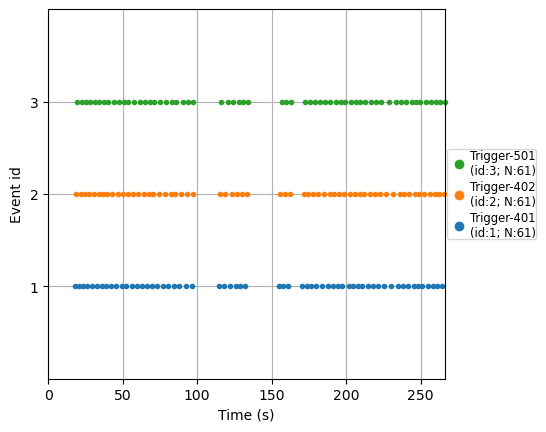

In [8]:
# Extract events 

fig = mne.viz.plot_events(events, sfreq=sfreq, event_id=event_id);

### **Electrode positions**

In [9]:
# Load electrode metadata
electrodes_tsv = 'ds005545-download/sub-80/ses-01/ieeg/sub-80_ses-01_electrodes.tsv'
electrode_positions = pd.read_csv(electrodes_tsv, sep='\t')

# Display electrode positions
print(electrode_positions.head())

  name          x          y          z  size
0   A3 -50.106579 -58.395985  23.277752     0
1   A4 -59.254402 -54.785877  15.215353     0
2   A5 -59.978233 -40.066578  39.257343     0
3   A6 -45.325970 -28.038254  37.129173     0
4   A7 -54.598400 -25.692129  44.675392     0


In [10]:
from mne.datasets import fetch_fsaverage
from mne.transforms import Transform, apply_trans


# Prepare electrode positions for MNE montage
elec_names = electrode_positions['name'].values.tolist()  # Convert to a list
elec_positions = electrode_positions[['x', 'y', 'z']].values / 1000  # Convert from mm to meters

# Define fiducial points for head coordinates (replace with actual positions in meters)
fiducials = {
    'nasion': np.array([0, 0.1, 0]),
    'lpa': np.array([-0.1, 0, 0]),
    'rpa': np.array([0.1, 0, 0]),
}

# Combine fiducial and electrode positions
ch_pos = {name: pos for name, pos in zip(elec_names, elec_positions)}
ch_pos.update(fiducials)  # Add fiducials to channel positions

# Create a montage with fiducials
montage = mne.channels.make_dig_montage(
    ch_pos=ch_pos,
    coord_frame='head'  # Use 'head' as the coordinate frame
)

# Create an `info` object for the electrodes
info = mne.create_info(
    ch_names=elec_names,
    sfreq=1000,  # Replace with your sampling frequency
    ch_types="seeg"  # Specify the channel type
)
info.set_montage(montage)  # Set the montage to the info object

# Fetch fsaverage template for visualization
sample_path = mne.datasets.sample.data_path()
subjects_dir = sample_path / "subjects"
fetch_fsaverage(subjects_dir=subjects_dir, verbose=True)

# Perform coregistration to compute head->MRI transform
trans = mne.transforms.Transform(
    fro="head", to="mri", trans=np.eye(4)  # Identity matrix as a placeholder
)  # Replace with a valid coregistration matrix if available

# Visualize electrode positions on fsaverage
brain = mne.viz.Brain(
    "fsaverage",
    subjects_dir=subjects_dir,
    cortex="low_contrast",
    alpha=0.25,
    background="white",
)

# Add electrodes to the brain visualization
brain.add_sensors(info, trans=trans)  # Use the computed transformation

# Show the view
brain.show_view(azimuth=120, elevation=100, distance=400)

# **Apply the Transformation to the Montage (Important Step)**
# Extract the electrode positions
ch_pos = montage.get_positions()['ch_pos']

# Apply the head-to-MRI transform to each electrode
transformed_positions = {}
for ch_name, pos in ch_pos.items():
    # Apply the transformation to each electrode position
    transformed_pos = apply_trans(trans['trans'], pos)
    transformed_positions[ch_name] = transformed_pos

# Update the montage with the transformed positions
montage = mne.channels.make_dig_montage(
    ch_pos=transformed_positions,
    coord_frame='mri'  # Update the coordinate frame to 'mri'
)

# **Now, Get Volume Labels**
# Map electrode positions to anatomical regions
labels, colors = mne.get_montage_volume_labels(
    montage, "fsaverage", subjects_dir=subjects_dir, aseg="aparc+aseg"
)



c:\Users\lacom\.conda\envs\xtra\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


0 files missing from root.txt in C:\Users\lacom\mne_data\MNE-sample-data\subjects
0 files missing from bem.txt in C:\Users\lacom\mne_data\MNE-sample-data\subjects\fsaverage
False


In [11]:
# Accessing and indexing epochs by condition
evoked_1 = epochs['Trigger-401'].average()
evoked_2 = epochs['Trigger-402'].average()

C:\Users\lacom\AppData\Local\Temp\ipykernel_10332\1749978461.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = evoked_1.plot(spatial_colors=True,titles='Evoked 1')


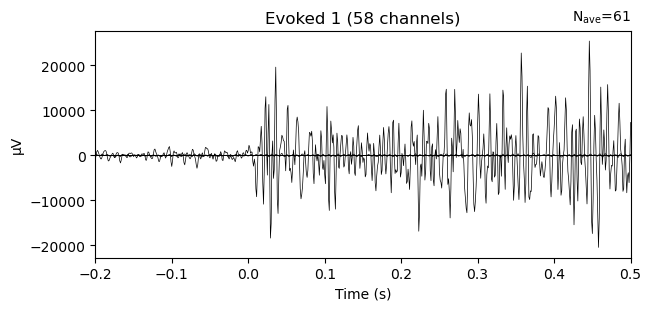

C:\Users\lacom\AppData\Local\Temp\ipykernel_10332\1749978461.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = evoked_2.plot(spatial_colors=True,titles='Evoked 2')


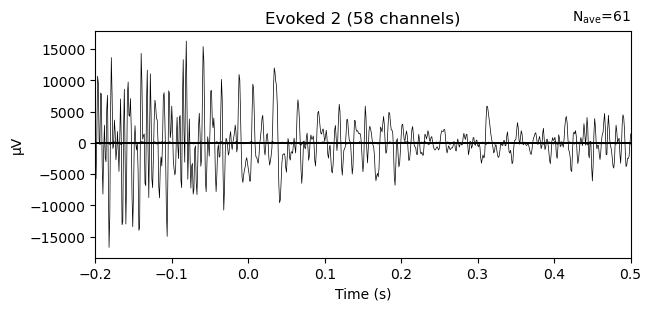

In [12]:
fig = evoked_1.plot(spatial_colors=True,titles='Evoked 1')
fig = evoked_2.plot(spatial_colors=True,titles='Evoked 2')

### Machine Learning

In [13]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from mne.decoding import SlidingEstimator, cross_val_multiscore

In [14]:
#To keep chance level at 50% accuracy, we first equalize the number of epochs in each condition.
epochs.equalize_event_counts(event_id)

# Separate auditory and visual epochs
Trigger1_epochs = epochs['Trigger-401']
Trigger2_epochs = epochs['Trigger-402']

# Print information about the equalized epochs
print(Trigger1_epochs)
print(Trigger2_epochs)

<EpochsFIF | 61 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~19.0 MiB, data loaded,
 'Trigger-401': 61>
<EpochsFIF | 61 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~19.0 MiB, data loaded,
 'Trigger-402': 61>


In [15]:

def preprocess_epochs_to_dataframe(epochs, event_id, event_conditions, pick_eeg=True):
    """
    Preprocess EEG epochs data into a flattened DataFrame with channel-timepoint features and labels.
    
    Parameters:
    - epochs: The Epochs object containing EEG data (mne.Epochs).
    - event_id: A dictionary mapping event names to event IDs (e.g., {'auditory/left': 1, 'visual/right': 2}).
    - event_conditions: A list of event conditions to consider for labeling (e.g., ['auditory/left', 'visual/right']).
    - pick_eeg: Whether to select only EEG channels (default is True).
    
    Returns:
    - X_df: A pandas DataFrame with flattened EEG data and corresponding labels.
    """
    
    # Step 1: Select only EEG channels if specified
    if pick_eeg:
        epochs = epochs.pick_types(eeg=True)
    
    # Get the data (shape: [n_epochs, n_channels, n_timepoints])
    X = epochs.get_data()  # Shape: (n_epochs, n_channels, n_timepoints)
    
    # Step 2: Create feature names (channel-timepoint pairs)
    feature_names = []
    n_channels = X.shape[1]
    n_timepoints = X.shape[2]

    for ch in range(n_channels):  # Iterate over EEG channels
        for t in range(n_timepoints):  # Iterate over time points
            feature_names.append(f"Channel_{ch}_Time_{t}")
    
    # Step 3: Flatten the data (preserving channel-timepoint structure)
    X_flattened = X.reshape(X.shape[0], -1)  # Shape: (n_epochs, n_channels * n_timepoints)

    # Step 4: Initialize the label array
    y = np.empty(len(epochs.events), dtype=int)
    
    # Step 5: Assign labels based on event conditions
    for condition in event_conditions:
        idx_condition = epochs.events[:, 2] == event_id[condition]
        y[idx_condition] = event_conditions.index(condition)  # Assign labels based on condition order
    
    # Step 6: Create a DataFrame with flattened data and feature names
    X_df = pd.DataFrame(X_flattened, columns=feature_names)
    
    # Step 7: Add the labels to the DataFrame (optional)
    X_df['label'] = y
    
    # Step 8: Return the DataFrame with features and labels
    return X_df



In [16]:
# Define the event conditions you want to label
event_conditions = ['Trigger-401', 'Trigger-402', 'Trigger-501'] 
# Assuming 'epochs' is your MNE Epochs object
X_df = preprocess_epochs_to_dataframe(epochs, event_id, event_conditions)

# Check the first few rows of the resulting DataFrame
X_df.head()

,Channel_0_Time_0,Channel_0_Time_1,Channel_0_Time_2,Channel_0_Time_3,Channel_0_Time_4,Channel_0_Time_5,Channel_0_Time_6,Channel_0_Time_7,Channel_0_Time_8,Channel_0_Time_9,...,Channel_57_Time_692,Channel_57_Time_693,Channel_57_Time_694,Channel_57_Time_695,Channel_57_Time_696,Channel_57_Time_697,Channel_57_Time_698,Channel_57_Time_699,Channel_57_Time_700,label
0,-0.000011,-0.000012,-0.000016,-0.000020,-0.000022,-0.000022,-0.000019,-0.000016,-0.000013,-1.049401e-05,...,0.001639,0.002620,0.002139,0.001202,-0.000082,-0.001172,-0.000432,0.002022,0.003344,0
1,-0.000025,-0.000019,-0.000014,-0.000010,-0.000007,-0.000003,0.000001,0.000004,0.000004,2.999592e-06,...,0.002184,0.002309,0.000485,-0.001431,-0.002066,-0.001441,-0.000319,0.000343,-0.000140,1
2,0.000044,0.000037,0.000030,0.000024,0.000020,0.000018,0.000016,0.000014,0.000009,-2.581648e-07,...,-0.000560,-0.000177,0.001106,0.002279,0.001239,-0.001394,-0.003035,-0.002522,-0.000424,2
3,-0.000015,-0.000016,-0.000017,-0.000020,-0.000023,-0.000028,-0.000035,-0.000044,-0.000052,-5.765380e-05,...,-0.001858,-0.001510,-0.000533,0.001715,0.003464,0.002164,-0.001070,-0.002723,-0.001788,0
4,-0.000020,-0.000017,-0.000013,-0.000011,-0.000013,-0.000017,-0.000022,-0.000027,-0.000033,-3.788784e-05,...,0.000528,-0.000345,-0.000646,0.001057,0.002725,0.001531,-0.001288,-0.002602,-0.002003,1


In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


# Assuming 'X_df' is the DataFrame with flattened EEG data and labels
# And that 'y' is the array with the corresponding labels
X = X_df.drop(columns='label')  # Features (drop the label column)
y = X_df['label']  # Labels

# Step 1: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [18]:

# Step 2: Define the best hyperparameters based on grid search results
best_params = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 100,
    'subsample': 0.8
}

# Step 3: Set up the XGBoost classifier with the best hyperparameters
xgb = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='mlogloss',
    **best_params  # Apply the best hyperparameters here
)

# Step 4: Fit the XGBoost model on the training data
xgb.fit(X_train, y_train)

# Step 5: Make predictions on the test data
y_pred = xgb.predict(X_test)

# Step 6: Evaluate the model performance using accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with best hyperparameters: {accuracy:.4f}")


c:\Users\lacom\.conda\envs\xtra\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:05:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy with best hyperparameters: 0.8108


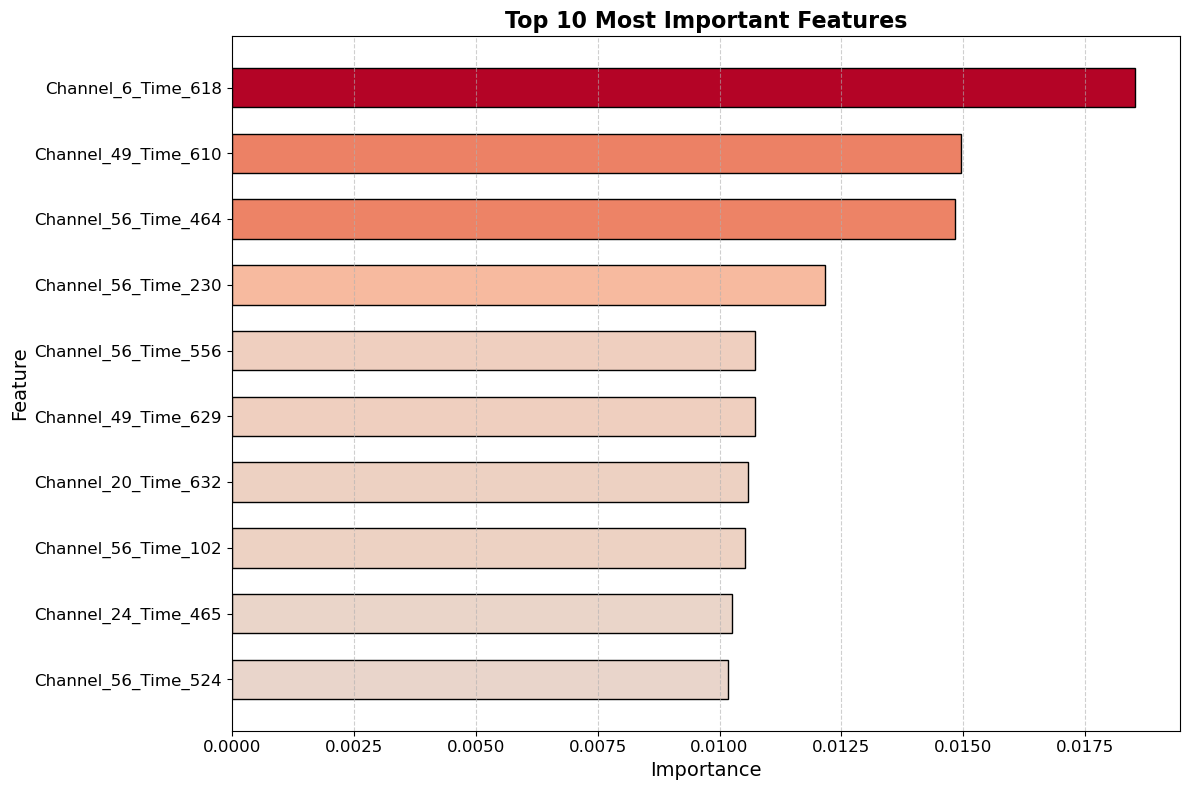

,feature,importance
4824,Channel_6_Time_618,0.018518
34959,Channel_49_Time_610,0.014942
39720,Channel_56_Time_464,0.014831
39486,Channel_56_Time_230,0.012157
39812,Channel_56_Time_556,0.010727
34978,Channel_49_Time_629,0.010723
14652,Channel_20_Time_632,0.010592
39358,Channel_56_Time_102,0.010517
17289,Channel_24_Time_465,0.010266
39780,Channel_56_Time_524,0.010174


In [19]:
# Get feature importance from the trained model
importances = xgb.feature_importances_

# Step 10: Create a DataFrame of feature importances (with channel-timepoint as the feature names)
feature_importances_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

# Sort the DataFrame by importance
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False)

# Step 11: Visualize the top 10 most important features
top_10_features = feature_importances_df.head(10)

# Set up the plot
plt.figure(figsize=(12, 8))

# Create a color palette based on importance values (from light to dark)
bar_colors = sns.color_palette("coolwarm", as_cmap=True)

# Create the horizontal bar plot
bars = plt.barh(top_10_features['feature'], top_10_features['importance'], 
                color=bar_colors(top_10_features['importance'] / max(top_10_features['importance'])), 
                edgecolor='black', height=0.6)


# Make the title and labels more readable
plt.title('Top 10 Most Important Features', fontsize=16, fontweight='bold')
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)

# Invert the y-axis to display the most important feature at the top
plt.gca().invert_yaxis()

# Customize the grid
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

# Step 12: Optionally, output the top important features for further analysis
top_10_features
